<a href="https://colab.research.google.com/github/Ravravan/ML-projects/blob/main/Gold_Prise_Prediction_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Importing the libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics

#Data collection and Processing

In [3]:
#loading the csv data
gold_data = pd.read_csv('/content/gld_price_data.csv')

In [4]:
gold_data.head()

,Date,SPX,GLD,USO,SLV,EUR/USD
0,1/2/2008,1447.160034,84.860001,78.470001,15.180,1.471692
1,1/3/2008,1447.160034,85.570000,78.370003,15.285,1.474491
2,1/4/2008,1411.630005,85.129997,77.309998,15.167,1.475492
3,1/7/2008,1416.180054,84.769997,75.500000,15.053,1.468299
4,1/8/2008,1390.189941,86.779999,76.059998,15.590,1.557099


In [5]:
#print last 5 rows
gold_data.tail()

,Date,SPX,GLD,USO,SLV,EUR/USD
2285,5/8/2018,2671.919922,124.589996,14.0600,15.5100,1.186789
2286,5/9/2018,2697.790039,124.330002,14.3700,15.5300,1.184722
2287,5/10/2018,2723.070068,125.180000,14.4100,15.7400,1.191753
2288,5/14/2018,2730.129883,124.489998,14.3800,15.5600,1.193118
2289,5/16/2018,2725.780029,122.543800,14.4058,15.4542,1.182033


In [6]:
#numbers of rows and columns
gold_data.shape

(2290, 6)

In [7]:
#getting basic info about the data
gold_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2290 entries, 0 to 2289
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     2290 non-null   object 
 1   SPX      2290 non-null   float64
 2   GLD      2290 non-null   float64
 3   USO      2290 non-null   float64
 4   SLV      2290 non-null   float64
 5   EUR/USD  2290 non-null   float64
dtypes: float64(5), object(1)
memory usage: 107.5+ KB


In [8]:
#checking the number of missing values
gold_data.isnull().sum()

,0
Date,0
SPX,0
GLD,0
USO,0
SLV,0
EUR/USD,0


In [9]:
#geting  the statical measure of the data
gold_data.describe()

,SPX,GLD,USO,SLV,EUR/USD
count,2290.000000,2290.000000,2290.000000,2290.000000,2290.000000
mean,1654.315776,122.732875,31.842221,20.084997,1.283653
std,519.111540,23.283346,19.523517,7.092566,0.131547
min,676.530029,70.000000,7.960000,8.850000,1.039047
25%,1239.874969,109.725000,14.380000,15.570000,1.171313
50%,1551.434998,120.580002,33.869999,17.268500,1.303297
75%,2073.010070,132.840004,37.827501,22.882500,1.369971
max,2872.870117,184.589996,117.480003,47.259998,1.598798


#Correlation:


1.   Positive Correlation
2.   Negative Correlation



In [11]:
correlation = gold_data.drop('Date', axis=1).corr()

<Axes: >

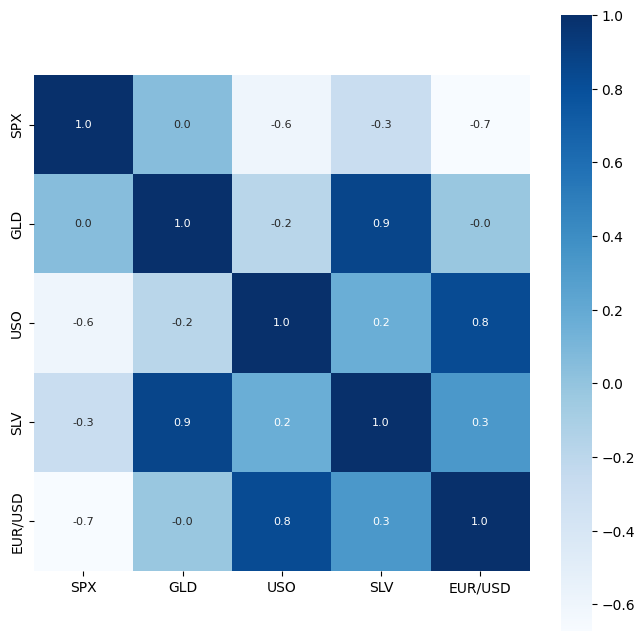

In [13]:
plt.figure(figsize=(8,8))
sns.heatmap(correlation, cbar=True, square=True, fmt='.1f',annot=True,annot_kws={'size':8},cmap='Blues')

In [14]:
#correlation values of GLD
print(correlation['GLD'])

SPX        0.049345
GLD        1.000000
USO       -0.186360
SLV        0.866632
EUR/USD   -0.024375
Name: GLD, dtype: float64


/tmp/ipykernel_3186/121492338.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(gold_data['GLD'],color='green')


<Axes: xlabel='GLD', ylabel='Density'>

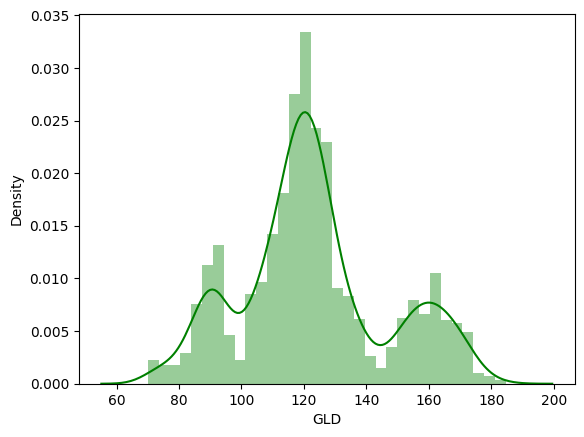

In [16]:
#checking the distribution of the GLD prise
sns.distplot(gold_data['GLD'],color='green')

Splitting the features and targets

In [21]:
X = gold_data.drop(['Date','GLD'],axis=1)
Y = gold_data['GLD']

In [22]:
print(X)

              SPX        USO      SLV   EUR/USD
0     1447.160034  78.470001  15.1800  1.471692
1     1447.160034  78.370003  15.2850  1.474491
2     1411.630005  77.309998  15.1670  1.475492
3     1416.180054  75.500000  15.0530  1.468299
4     1390.189941  76.059998  15.5900  1.557099
...           ...        ...      ...       ...
2285  2671.919922  14.060000  15.5100  1.186789
2286  2697.790039  14.370000  15.5300  1.184722
2287  2723.070068  14.410000  15.7400  1.191753
2288  2730.129883  14.380000  15.5600  1.193118
2289  2725.780029  14.405800  15.4542  1.182033

[2290 rows x 4 columns]


In [23]:
print(Y)

0        84.860001
1        85.570000
2        85.129997
3        84.769997
4        86.779999
           ...    
2285    124.589996
2286    124.330002
2287    125.180000
2288    124.489998
2289    122.543800
Name: GLD, Length: 2290, dtype: float64


In [24]:
X_train,X_test,Y_train,Y_test  = train_test_split(X,Y,test_size=0.2,random_state=2)

#Model traning

In [25]:
regressor = RandomForestRegressor(n_estimators=100)

In [27]:
#trainig the model
regressor.fit(X_train,Y_train)

RandomForestRegressor()

Model Evaluation

In [28]:
#prediction on test data
test_data_prediction = regressor.predict(X_test)

In [29]:
print(test_data_prediction)

[168.5786995   82.0372999  115.98050016 127.62930076 120.68950134
 154.88709821 150.23789879 126.21689992 117.55439916 125.95460108
 116.63250098 172.40730117 141.46869785 167.77949811 115.25620004
 117.46630061 138.50290313 170.07420064 159.30270285 159.6085993
 155.15899953 125.4791     176.3840992  157.04100298 125.17190071
  94.05359999  76.79440033 120.34790024 119.07699959 167.51250028
  88.1878008  125.17569966  91.1324006  117.60840018 121.11509932
 136.35280084 115.45920104 115.11780079 147.5547995  107.36210124
 104.25380238  87.28989787 126.66120044 117.8503999  152.17819934
 119.52119992 108.33890006 108.45899825  93.35880071 127.04359822
  74.86130073 113.53489917 121.75789995 111.23889912 118.79159886
 121.02619939 159.60520011 167.46390108 146.94469667  85.83699872
  94.39130026  86.8516989   90.56789989 118.86090094 126.46420083
 127.46919995 168.12700035 122.27559912 117.42369904  98.66590033
 167.84530185 142.96589834 132.62820265 121.14550203 121.1621993
 119.7582005

In [31]:
#r2 error
error_score = metrics.r2_score(test_data_prediction,Y_test)

In [34]:
print("R squared error:", error_score)

R squared error: 0.9889945104826824


#Compare Actual values and predicted values

In [36]:
Y_test = list(Y_test)

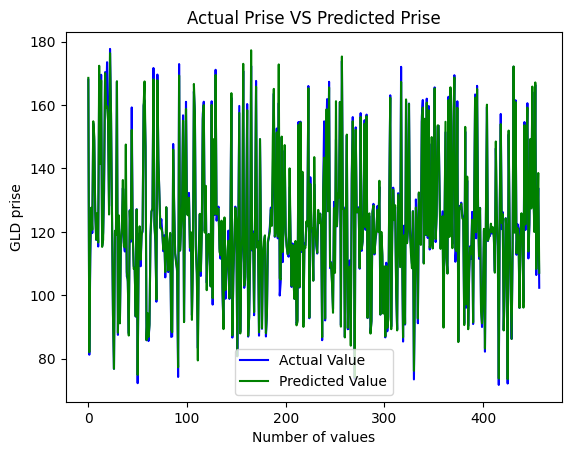

In [39]:
plt.plot(Y_test, color='blue',label='Actual Value')
plt.plot(test_data_prediction, color='green',label='Predicted Value')
plt.title('Actual Prise VS Predicted Prise')
plt.xlabel('Number of values')
plt.ylabel('GLD prise')
plt.legend()
plt.show()